# Real Data

In [2]:
import pandas as pd

path = "/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/rf_augmented/ui_data/unique_bending_setups.csv"

bending_setup_df = pd.read_csv(path)

In [3]:
import ast
import pandas as pd


excluded_experiments = {1, 48, 166}


def remove_excluded_experiments(value):
    if isinstance(value, str):
        value = ast.literal_eval(value)

    if not isinstance(value, (list, tuple, set)):
        value = [value]

    return [
        int(exp_id)
        for exp_id in value
        if int(exp_id) not in excluded_experiments
    ]


bending_setup_df = pd.read_csv(path)
bending_setup_df["Experiment_Number"] = bending_setup_df[
    "Experiment_Number"
].apply(remove_excluded_experiments)

bending_setup_df = bending_setup_df[
    bending_setup_df["Experiment_Number"].apply(len) > 0
].reset_index(drop=True)

#bending_setup_df.head(4)

In [4]:
bending_setup_df = bending_setup_df.copy()

bending_setup_df.insert(
    0,
    "Group_ID",
    range(1, len(bending_setup_df) + 1)
)

## Per-split train vs test value comparison

Use the widget below to pick a `split_index` and a column from `bending_setup_df`.
Numeric columns show box+points for train vs test. Categorical columns show grouped counts.

In [5]:
import pandas as pd
import numpy as np
from itertools import product


# =============================================================================
# Configuration
# =============================================================================
df = bending_setup_df.copy()

group_col = "Group_ID"
exp_col = "Experiment_Number"

# Only these two features are used for splitting
important_split_features = {
    "Mandrel retraction timing": [
        0.0,
        2.0,
        5.0,
        10.0,
    ],
    "Collet boost": [
        0.85,
        0.87,
        0.90,
        0.92,
        0.95,
    ],
}


# =============================================================================
# Helper functions
# =============================================================================
def as_list(x):
    """
    Convert a scalar or list-like experiment value
    to a standard Python list.
    """
    if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
        return list(x)

    if pd.isna(x):
        return []

    return [x]


def format_value(value):
    """Format values for readable split names."""
    if isinstance(value, (float, np.floating)):
        return f"{float(value):g}"

    return str(value)


def count_experiments(input_df):
    """
    Count experiments when Experiment_Number may contain
    either scalar values or lists of values.
    """
    if input_df.empty:
        return 0

    return (
        input_df[exp_col]
        .apply(lambda x: len(as_list(x)))
        .sum()
    )


def create_group_level_split(input_df, test_row_mask):
    """
    Create a leakage-free split at Group_ID level.

    If at least one row of a group contains the held-out
    feature-value combination, the complete group is assigned
    to the test set.
    """
    test_groups = (
        input_df.loc[test_row_mask, group_col]
        .dropna()
        .unique()
        .tolist()
    )

    test_df = input_df[
        input_df[group_col].isin(test_groups)
    ].copy()

    train_df = input_df[
        ~input_df[group_col].isin(test_groups)
    ].copy()

    return (
        train_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def get_split_stats(
    split_name,
    train_df,
    test_df,
    test_condition,
):
    """Create summary information for one train/test split."""
    train_exp = count_experiments(train_df)
    test_exp = count_experiments(test_df)
    total_exp = train_exp + test_exp

    train_groups = sorted(
        train_df[group_col]
        .dropna()
        .unique()
        .tolist()
    )

    test_groups = sorted(
        test_df[group_col]
        .dropna()
        .unique()
        .tolist()
    )

    overlap_groups = sorted(
        set(train_groups).intersection(test_groups)
    )

    return {
        "Split name": split_name,
        "Split type": "Two-feature combination holdout",
        "Train condition": (
            "All groups except groups containing "
            "the held-out two-feature combination"
        ),
        "Test condition": test_condition,
        "Train groups": len(train_groups),
        "Test groups": len(test_groups),
        "Train Group_IDs": train_groups,
        "Test Group_IDs": test_groups,
        "Train experiments": train_exp,
        "Test experiments": test_exp,
        "Test experiment (%)": (
            round(100 * test_exp / total_exp, 2)
            if total_exp > 0
            else np.nan
        ),
        "Group overlap": overlap_groups,
    }


def get_available_configured_values(
    input_df,
    feature,
    configured_values,
):
    """
    Return only configured values that exist exactly
    in the dataset.
    """
    available_values = []

    for value in configured_values:
        if input_df[feature].eq(value).any():
            available_values.append(value)

    return available_values


# =============================================================================
# Validate required columns
# =============================================================================
required_columns = {
    group_col,
    exp_col,
    *important_split_features.keys(),
}

missing_columns = sorted(
    required_columns.difference(df.columns)
)

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )


# =============================================================================
# Generate two-feature combination splits
# =============================================================================
new_splits = {}
new_stats = []

feature_1 = "Mandrel retraction timing"
feature_2 = "Collet boost"

values_1 = get_available_configured_values(
    input_df=df,
    feature=feature_1,
    configured_values=important_split_features[feature_1],
)

values_2 = get_available_configured_values(
    input_df=df,
    feature=feature_2,
    configured_values=important_split_features[feature_2],
)

for value_1, value_2 in product(values_1, values_2):

    # Exact-value comparison
    test_row_mask = (
        df[feature_1].eq(value_1)
        & df[feature_2].eq(value_2)
    )

    # Skip combinations that do not exist in the dataset
    if not test_row_mask.any():
        continue

    train_df, test_df = create_group_level_split(
        input_df=df,
        test_row_mask=test_row_mask,
    )

    # Skip invalid splits
    if train_df.empty or test_df.empty:
        continue

    train_groups = set(
        train_df[group_col]
        .dropna()
        .unique()
    )

    test_groups = set(
        test_df[group_col]
        .dropna()
        .unique()
    )

    overlap = train_groups.intersection(test_groups)

    if overlap:
        raise ValueError(
            "Group leakage detected for "
            f"{feature_1}={value_1} and "
            f"{feature_2}={value_2}: {overlap}"
        )

    split_name = (
        f"pair"
        f"__{feature_1}={format_value(value_1)}"
        f"__AND"
        f"__{feature_2}={format_value(value_2)}"
    )

    new_splits[split_name] = {
        "train": train_df,
        "test": test_df,
    }

    new_stats.append(
        get_split_stats(
            split_name=split_name,
            train_df=train_df,
            test_df=test_df,
            test_condition={
                feature_1: value_1,
                feature_2: value_2,
                "logic": "AND",
            },
        )
    )


# =============================================================================
# Summary
# =============================================================================
new_split_summary_df = pd.DataFrame(new_stats)

if not new_split_summary_df.empty:
    new_split_summary_df = (
        new_split_summary_df
        .sort_values("Split name")
        .reset_index(drop=True)
    )


print(
    f"Available {feature_1} values: {values_1}"
)

print(
    f"Available {feature_2} values: {values_2}"
)

print(
    f"Number of generated splits: {len(new_splits)}"
)

#display(new_split_summary_df)

Available Mandrel retraction timing values: [0.0, 2.0, 5.0, 10.0]
Available Collet boost values: [0.85, 0.87, 0.9, 0.92, 0.95]
Number of generated splits: 18


## QRF runs for value-based splits

Run QRF for every row in `new_split_summary_df` across the real, within-group, and sensor-augmented geometry sources, then store all test-set prediction values for visualization in one CSV.


In [5]:
import ast
import json
import re
import sys
from pathlib import Path

import pandas as pd

from quantile_forest import RandomForestQuantileRegressor

project_root = Path.cwd().resolve()
if project_root.name == "exploration":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pipeline.ml.qrf.geometry_data_preprocessor import GeometryPreprocessor
from src.pipeline.ml.qrf.qrf_model_trainer import QRFModelTrainer
from src.pipeline.ml.qrf.qrf_pipeline import qrf_training_geometry_sources
from src.pipeline.rf_augmentation.io_utils import read_table


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

project_root = Path.cwd().resolve()

if not (project_root / "data").exists():
    project_root = project_root.parent

output_dir = project_root / "data" / "qrf" / "split"
model_dir = output_dir / "models"

output_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "various_splits.parquet"


# ---------------------------------------------------------------------
# Selected geometry source
# ---------------------------------------------------------------------

geometry_source = (
    "sensor_augmented_noise__time_wrapping__scaling__jittering"
)


# ---------------------------------------------------------------------
# QRF parameters
# ---------------------------------------------------------------------

qrf_params = {
    "n_estimators": 800,
    "max_depth": 5,
    "lower_quantile": 0.05,
    "upper_quantile": 0.95,
}

use_best_qrf_params = True


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def parse_experiment_numbers(value):
    if isinstance(value, str):
        value = ast.literal_eval(value)

    if isinstance(value, (list, tuple, set)):
        return [int(exp_id) for exp_id in value]

    return [int(value)]


def json_list(values):
    return json.dumps([int(value) for value in values])


def make_slug(value):
    slug = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        str(value),
    ).strip("_")

    return slug or "split"


def experiments_for_groups(group_ids):
    group_ids = [int(group_id) for group_id in group_ids]

    group_rows = bending_for_qrf[
        bending_for_qrf["Group_ID"].isin(group_ids)
    ]

    experiments = set()

    for experiment_numbers in group_rows["Experiment_Number"]:
        experiments.update(
            int(exp_id)
            for exp_id in experiment_numbers
        )

    return sorted(experiments)


def extract_split_label(split_row):
    split_column = split_row.get("Split column")
    test_value = split_row.get("Test value")

    if pd.notna(split_column) and pd.notna(test_value):
        return split_column, test_value

    split_name = split_row.get("Split name")

    if isinstance(split_name, str) and split_name:
        return "split", split_name

    test_condition = split_row.get("Test condition")

    if isinstance(test_condition, dict):
        feature_names = [
            key
            for key in test_condition.keys()
            if key != "logic"
        ]

        if feature_names:
            feature = feature_names[0]
            return feature, test_condition[feature]

    return "split", "unknown"


# ---------------------------------------------------------------------
# Prepare bending data
# ---------------------------------------------------------------------

bending_for_qrf = bending_setup_df.copy()

if "Group_ID" not in bending_for_qrf.columns:
    bending_for_qrf.insert(
        0,
        "Group_ID",
        range(1, len(bending_for_qrf) + 1),
    )

bending_for_qrf["Experiment_Number"] = (
    bending_for_qrf["Experiment_Number"]
    .apply(parse_experiment_numbers)
)


# ---------------------------------------------------------------------
# Load only the selected augmented geometry source
# ---------------------------------------------------------------------

available_geometry_sources = qrf_training_geometry_sources(
    project_root
)

if geometry_source not in available_geometry_sources:
    raise KeyError(
        f"Geometry source '{geometry_source}' was not found. "
        f"Available sources: {list(available_geometry_sources.keys())}"
    )

geometry_path = available_geometry_sources[geometry_source]

print(f"Loading geometry source: {geometry_source}")
print(f"Geometry path: {geometry_path}")

geometry = read_table(geometry_path)

geometry_clean = GeometryPreprocessor.preprocess(
    geometry_df=geometry,
    bending_df=bending_for_qrf,
)

print(
    f"Loaded and preprocessed "
    f"{len(geometry_clean):,} geometry rows."
)


# ---------------------------------------------------------------------
# Get split summary dataframe
# ---------------------------------------------------------------------

summary_df = globals().get(
    "new_split_summary_df",
    globals().get("split_summary_df"),
)

if summary_df is None:
    raise NameError(
        "No split summary dataframe is available in the notebook scope. "
        "Expected 'new_split_summary_df' or 'split_summary_df'."
    )

if summary_df.empty:
    raise ValueError(
        "The split summary dataframe is empty."
    )


# ---------------------------------------------------------------------
# Train and predict for every split
# ---------------------------------------------------------------------

all_prediction_rows = []

for split_position, (split_idx, split_row) in enumerate(
    summary_df.iterrows(),
    start=1,
):
    split_column, test_value = extract_split_label(
        split_row
    )

    split_name = f"{split_column} = {test_value}"

    split_slug = (
        f"{split_position - 1:03d}_"
        f"{make_slug(split_column)}_"
        f"{make_slug(test_value)}"
    )

    train_group_ids = [
        int(group_id)
        for group_id in split_row["Train Group_IDs"]
    ]

    test_group_ids = [
        int(group_id)
        for group_id in split_row["Test Group_IDs"]
    ]

    train_experiment_ids = experiments_for_groups(
        train_group_ids
    )

    test_experiment_ids = experiments_for_groups(
        test_group_ids
    )

    overlapping_group_ids = sorted(
        set(train_group_ids)
        & set(test_group_ids)
    )

    overlapping_experiment_ids = sorted(
        set(train_experiment_ids)
        & set(test_experiment_ids)
    )

    print(
        f"\nRunning split "
        f"{split_position}/{len(summary_df)}: "
        f"{split_name}"
    )

    print(
        f"  Geometry source: {geometry_source}"
    )

    print(
        f"  Train groups: {len(train_group_ids)}"
    )

    print(
        f"  Test groups: {len(test_group_ids)}"
    )

    print(
        f"  Overlapping groups: "
        f"{len(overlapping_group_ids)}"
    )

    print(
        f"  Train experiments: "
        f"{len(train_experiment_ids)}"
    )

    print(
        f"  Test experiments: "
        f"{len(test_experiment_ids)}"
    )

    print(
        f"  Overlapping experiments: "
        f"{len(overlapping_experiment_ids)}"
    )

    train_df = geometry_clean[
        geometry_clean["Group_ID"].isin(
            train_group_ids
        )
    ].copy()

    test_df = geometry_clean[
        geometry_clean["Group_ID"].isin(
            test_group_ids
        )
    ].copy()

    if train_df.empty:
        raise ValueError(
            f"Empty train_df for split "
            f"{split_idx}: {split_name}, "
            f"dataset={geometry_source}"
        )

    if test_df.empty:
        raise ValueError(
            f"Empty test_df for split "
            f"{split_idx}: {split_name}, "
            f"dataset={geometry_source}"
        )

    print(
        f"  Train rows: {len(train_df):,}"
    )

    print(
        f"  Test rows: {len(test_df):,}"
    )

    selected_qrf_params = (
        qrf_params
        if use_best_qrf_params
        else {}
    )

    training_result = QRFModelTrainer.train(
        train_df=train_df,
        test_df=test_df,
        model_dir=model_dir,
        paper_name=(
            f"qrf_geometry_"
            f"{geometry_source}_"
            f"{split_slug}"
        ),
        use_mlflow=False,
        **selected_qrf_params,
    )

    target_predictions = [
        (
            "Main-axis [mm]",
            training_result["main"]["prediction_df"],
        ),
        (
            "Secondary-axis [mm]",
            training_result["secondary"]["prediction_df"],
        ),
    ]

    for target, prediction_df in target_predictions:
        prediction_df = prediction_df.copy()

        if len(prediction_df) != len(test_df):
            raise ValueError(
                f"Prediction row count does not match test row count "
                f"for split={split_name}, "
                f"target={target}. "
                f"Predictions={len(prediction_df)}, "
                f"test_df={len(test_df)}"
            )

        prediction_df["Experiment_ID"] = (
            test_df["Experiment_ID"].to_numpy()
        )

        prediction_df["inside_interval"] = (
            (
                prediction_df["y_true"]
                >= prediction_df["y_pred_lower"]
            )
            & (
                prediction_df["y_true"]
                <= prediction_df["y_pred_upper"]
            )
        )

        prediction_df = prediction_df.rename(
            columns={
                "Angle[degree]": "angle",
            }
        )

        prediction_df["split_name"] = split_name
        prediction_df["split_index"] = int(
            split_position - 1
        )
        prediction_df["summary_df_index"] = str(
            split_idx
        )
        prediction_df["split_column"] = (
            split_column
        )
        prediction_df["test_value"] = (
            test_value
        )
        prediction_df["geometry_source"] = (
            geometry_source
        )
        prediction_df["target"] = target

        prediction_df["train_group_ids"] = (
            json_list(train_group_ids)
        )

        prediction_df["test_group_ids"] = (
            json_list(test_group_ids)
        )

        prediction_df["train_experiment_ids"] = (
            json_list(train_experiment_ids)
        )

        prediction_df["test_experiment_ids"] = (
            json_list(test_experiment_ids)
        )

        prediction_df["overlapping_group_ids"] = (
            json_list(overlapping_group_ids)
        )

        prediction_df[
            "overlapping_experiment_ids"
        ] = json_list(
            overlapping_experiment_ids
        )

        prediction_df[
            "test_experiment_percent"
        ] = split_row.get(
            "Test experiment (%)",
            pd.NA,
        )

        required_columns = [
            "split_index",
            "summary_df_index",
            "split_name",
            "split_column",
            "test_value",
            "geometry_source",
            "target",
            "Group_ID",
            "Experiment_ID",
            "angle",
            "y_true",
            "y_pred_median",
            "y_pred_lower",
            "y_pred_upper",
            "inside_interval",
            "train_group_ids",
            "test_group_ids",
            "train_experiment_ids",
            "test_experiment_ids",
            "overlapping_group_ids",
            "overlapping_experiment_ids",
            "test_experiment_percent",
        ]

        missing_columns = [
            column
            for column in required_columns
            if column not in prediction_df.columns
        ]

        if missing_columns:
            raise KeyError(
                f"Missing prediction columns for "
                f"split={split_name}, "
                f"target={target}: "
                f"{missing_columns}"
            )

        all_prediction_rows.append(
            prediction_df[required_columns]
        )


# ---------------------------------------------------------------------
# Store all split predictions in one Parquet file
# ---------------------------------------------------------------------

if not all_prediction_rows:
    raise ValueError(
        "No prediction rows were generated."
    )

various_splits_df = pd.concat(
    all_prediction_rows,
    ignore_index=True,
)

various_splits_df.to_parquet(
    output_path,
    index=False,
)

print(
    f"\nSaved "
    f"{len(various_splits_df):,} prediction rows "
    f"to:\n{output_path}"
)

print(
    f"Geometry source used for all splits:\n"
    f"{geometry_source}"
)

print(
    f"Number of processed splits: "
    f"{various_splits_df['split_index'].nunique()}"
)

print(
    f"Targets: "
    f"{various_splits_df['target'].unique().tolist()}"
)

2026-07-19 11:37:45,644 | INFO | src.logging.log_utils | Started GeometryPreprocessor.preprocess
2026-07-19 11:37:45,651 | INFO | src.logging.log_utils | Finished GeometryPreprocessor.preprocess
2026-07-19 11:37:45,653 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-19 11:37:45,654 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...


Loading geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
Geometry path: /Users/soroureskandari/Master Thesis /tube-bending-geometry/data/rf_augmented/ui_data/final_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering.csv
Loaded and preprocessed 27,000 geometry rows.

Running split 1/18: split = pair__Mandrel retraction timing=0__AND__Collet boost=0.85
  Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
  Train groups: 96
  Test groups: 4
  Overlapping groups: 0
  Train experiments: 301
  Test experiments: 14
  Overlapping experiments: 0
  Train rows: 25,920
  Test rows: 1,080


2026-07-19 11:38:02,910 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_000_split_pair__Mandrel_retraction_timing_0__AND__Collet_boost_0.85.pkl
2026-07-19 11:38:02,911 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_000_split_pair__Mandrel_retraction_timing_0__AND__Collet_boost_0.85.pkl
2026-07-19 11:38:02,911 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train
2026-07-19 11:38:02,918 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-19 11:38:02,919 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...



Running split 2/18: split = pair__Mandrel retraction timing=0__AND__Collet boost=0.87
  Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
  Train groups: 96
  Test groups: 4
  Overlapping groups: 0
  Train experiments: 301
  Test experiments: 14
  Overlapping experiments: 0
  Train rows: 25,920
  Test rows: 1,080


2026-07-19 11:38:19,815 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_pair__Mandrel_retraction_timing_0__AND__Collet_boost_0.87.pkl
2026-07-19 11:38:19,815 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_001_split_pair__Mandrel_retraction_timing_0__AND__Collet_boost_0.87.pkl
2026-07-19 11:38:19,816 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train
2026-07-19 11:38:19,823 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-19 11:38:19,824 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...


...


Running split 17/18: split = pair__Mandrel retraction timing=5__AND__Collet boost=0.92
  Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
  Train groups: 96
  Test groups: 4
  Overlapping groups: 0
  Train experiments: 301
  Test experiments: 14
  Overlapping experiments: 0
  Train rows: 25,920
  Test rows: 1,080


2026-07-19 11:42:26,079 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_016_split_pair__Mandrel_retraction_timing_5__AND__Collet_boost_0.92.pkl
2026-07-19 11:42:26,079 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_016_split_pair__Mandrel_retraction_timing_5__AND__Collet_boost_0.92.pkl
2026-07-19 11:42:26,080 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train
2026-07-19 11:42:26,087 | INFO | src.logging.log_utils | Started QRFModelTrainer.train
2026-07-19 11:42:26,088 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | Training QRF models...



Running split 18/18: split = pair__Mandrel retraction timing=5__AND__Collet boost=0.95
  Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering
  Train groups: 96
  Test groups: 4
  Overlapping groups: 0
  Train experiments: 301
  Test experiments: 14
  Overlapping experiments: 0
  Train rows: 25,920
  Test rows: 1,080


2026-07-19 11:42:42,657 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] MAIN → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_main_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_017_split_pair__Mandrel_retraction_timing_5__AND__Collet_boost_0.95.pkl
2026-07-19 11:42:42,657 | INFO | src.pipeline.ml.qrf.qrf_model_trainer | [SAVED] SECONDARY → /Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models/qrf_secondary_axis_qrf_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering_017_split_pair__Mandrel_retraction_timing_5__AND__Collet_boost_0.95.pkl
2026-07-19 11:42:42,659 | INFO | src.logging.log_utils | Finished QRFModelTrainer.train



Saved 54,000 prediction rows to:
/Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/various_splits.parquet
Geometry source used for all splits:
sensor_augmented_noise__time_wrapping__scaling__jittering
Number of processed splits: 18
Targets: ['Main-axis [mm]', 'Secondary-axis [mm]']


## Filter Split

In [6]:
from pathlib import Path
import json
import re

import joblib
import pandas as pd


def _paper_name_from_path(path, prefix, suffix):
    name = path.name
    return name[len(prefix):-len(suffix)]


def _parse_paper_name(paper_name):
    match = re.match(
        r"^qrf_geometry_(?P<geometry_source>.+)_(?P<split_index>\d+)_"
        r"(?P<split_kind>split_(?:single|pair|triple))__(?P<split_spec>.+)$",
        paper_name,
    )
    if not match:
        return {}

    out = match.groupdict()
    out["split_index"] = int(out["split_index"])
    return out


def _read_config(config_path):
    if config_path is None or not config_path.exists():
        return {}

    with config_path.open() as f:
        config = json.load(f)

    return {f"config_{k}": v for k, v in config.items()}


def _read_metrics(metrics_path):
    if metrics_path is None or not Path(metrics_path).exists():
        return None

    metrics_path = Path(metrics_path)

    if metrics_path.suffix == ".parquet":
        metrics = pd.read_parquet(metrics_path)
    else:
        metrics = pd.read_csv(metrics_path)

    required = {"geometry_source", "split_index", "target"}
    if not required.issubset(metrics.columns):
        return None

    metric_cols = [
        c for c in metrics.columns
        if c not in {"geometry_source", "split_index", "split_name", "target"}
    ]

    rows = []
    for keys, g in metrics.groupby(["geometry_source", "split_index"], dropna=False):
        row = {
            "geometry_source": keys[0],
            "split_index": keys[1],
        }

        if "split_name" in g.columns:
            names = g["split_name"].dropna().unique()
            if len(names):
                row["metric_split_name"] = names[0]

        for _, item in g.iterrows():
            axis = "main" if "Main" in str(item["target"]) else "secondary"
            for col in metric_cols:
                row[f"{axis}_{col}"] = item[col]

        rows.append(row)

    return pd.DataFrame(rows)


def build_qrf_split_models_df(
    model_dir="/Users/soroureskandari/Master Thesis /tube-bending-geometry/exploration/data/qrf/split/models",
    metrics_path="/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/qrf/split/qrf_interval_metrics_by_split.parquet",
    load_models=True,
):
    model_dir = Path(model_dir)

    main_paths = {
        _paper_name_from_path(p, "qrf_main_axis_", ".pkl"): p
        for p in model_dir.glob("qrf_main_axis_*.pkl")
    }

    secondary_paths = {
        _paper_name_from_path(p, "qrf_secondary_axis_", ".pkl"): p
        for p in model_dir.glob("qrf_secondary_axis_*.pkl")
    }

    config_paths = {
        _paper_name_from_path(p, "qrf_config_", ".json"): p
        for p in model_dir.glob("qrf_config_*.json")
    }

    paper_names = sorted(set(main_paths) | set(secondary_paths) | set(config_paths))
    rows = []

    for paper_name in paper_names:
        main_path = main_paths.get(paper_name)
        secondary_path = secondary_paths.get(paper_name)
        config_path = config_paths.get(paper_name)

        row = {
            "pkl_name": paper_name,
            "main_pkl_name": main_path.name if main_path else None,
            "secondary_pkl_name": secondary_path.name if secondary_path else None,
            "main_pkl_path": str(main_path) if main_path else None,
            "secondary_pkl_path": str(secondary_path) if secondary_path else None,
            "config_path": str(config_path) if config_path else None,
        }

        row.update(_parse_paper_name(paper_name))
        row.update(_read_config(config_path))

        if load_models:
            row["main"] = joblib.load(main_path) if main_path else None
            row["secondary"] = joblib.load(secondary_path) if secondary_path else None

        rows.append(row)

    df = pd.DataFrame(rows)

    metrics = _read_metrics(metrics_path)
    if metrics is not None:
        df = df.merge(
            metrics,
            on=["geometry_source", "split_index"],
            how="left",
        )

    return df

In [7]:
trained_model_df = build_qrf_split_models_df(load_models=True)

In [8]:
import numpy as np
import pandas as pd


# ============================================================
# Configuration
# ============================================================

SOURCE_TO_KEEP = (
    "sensor_augmented_noise__time_wrapping__scaling__jittering"
)

# Minimum acceptable prediction-interval coverage.
MIN_COVERAGE_PERCENT = 75.0

# Maximum acceptable absolute calibration error in percentage points.
MAX_CALIBRATION_ERROR = 20.0

# Compare models only inside the same split kind.
KEEP_SPLIT_KIND_SEPARATE = True

# Relative tolerances used to decide whether two model results are similar.
SIMILARITY_TOLERANCES = {
    "coverage": 0.05,
    "calibration": 0.20,
    "winkler": 0.15,
    "rmse": 0.10,
    "mae": 0.10,
    "bias": 0.15,
    "pinaw": 0.15,
}

# Weights used to rank similar models.
# Lower selection score is better.
SCORE_WEIGHTS = {
    "calibration": 0.25,
    "winkler": 0.25,
    "rmse": 0.15,
    "mae": 0.10,
    "bias": 0.10,
    "pinaw": 0.10,
    "coverage": 0.05,
}


# ============================================================
# General helper functions
# ============================================================

def robust_normalize(series):
    """
    Normalize a numeric series to the [0, 1] interval.

    Missing values receive the worst score, 1.
    Constant columns receive zero.
    """
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    valid = values.dropna()

    if valid.empty:
        return pd.Series(
            0.0,
            index=series.index,
            dtype=float,
        )

    lower = valid.quantile(0.05)
    upper = valid.quantile(0.95)

    if np.isclose(lower, upper):
        normalized = pd.Series(
            0.0,
            index=series.index,
            dtype=float,
        )
    else:
        clipped = values.clip(
            lower=lower,
            upper=upper,
        )

        normalized = (
            clipped - lower
        ) / (
            upper - lower
        )

    return normalized.fillna(1.0)


def relative_difference(value_a, value_b, epsilon=1e-12):
    """Calculate a scale-independent relative difference."""
    if pd.isna(value_a) or pd.isna(value_b):
        return np.inf

    value_a = float(value_a)
    value_b = float(value_b)

    denominator = max(
        abs(value_a),
        abs(value_b),
        epsilon,
    )

    return abs(value_a - value_b) / denominator


def make_hashable(value):
    """
    Convert nested objects into stable hashable representations.

    This allows duplicated() to work with columns containing lists,
    dictionaries, sets, or NumPy arrays.
    """
    if value is None:
        return None

    if isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, dict):
        return tuple(
            sorted(
                (
                    str(key),
                    make_hashable(item),
                )
                for key, item in value.items()
            )
        )

    if isinstance(value, (list, tuple)):
        return tuple(
            make_hashable(item)
            for item in value
        )

    if isinstance(value, set):
        return tuple(
            sorted(
                make_hashable(item)
                for item in value
            )
        )

    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass

    return value


def find_similarity_components(group, rows_are_similar_function):
    """
    Build connected components of similar model-result rows.
    """
    indices = group.index.tolist()

    parent = {
        index: index
        for index in indices
    }

    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]

        return index

    def union(index_a, index_b):
        root_a = find(index_a)
        root_b = find(index_b)

        if root_a != root_b:
            parent[root_b] = root_a

    for position, index_a in enumerate(indices):
        for index_b in indices[position + 1:]:
            if rows_are_similar_function(
                group.loc[index_a],
                group.loc[index_b],
            ):
                union(index_a, index_b)

    root_to_component = {}
    component_ids = {}

    for index in indices:
        root = find(index)

        if root not in root_to_component:
            root_to_component[root] = len(
                root_to_component
            )

        component_ids[index] = root_to_component[root]

    return component_ids


# ============================================================
# Input validation
# ============================================================

if "trained_model_df" not in globals():
    raise NameError(
        "trained_model_df is not available."
    )

if trained_model_df.empty:
    raise ValueError(
        "trained_model_df is empty."
    )

base_required_columns = [
    "geometry_source",
    "split_index",
    "split_kind",
    "split_spec",
]

axis_required_metrics = [
    "coverage_percent",
    "calibration_error",
    "winkler_score",
    "rmse_median",
    "mae_median",
    "bias_mean",
]

required_columns = base_required_columns.copy()

for axis_name in ("main", "secondary"):
    required_columns.extend(
        f"{axis_name}_{metric}"
        for metric in axis_required_metrics
    )

missing_columns = [
    column
    for column in required_columns
    if column not in trained_model_df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )


# ============================================================
# Independent axis-filtering pipeline
# ============================================================

def filter_splits_for_axis(
    input_df,
    axis,
):
    """
    Filter and rank split results for one axis independently.

    Parameters
    ----------
    input_df : pandas.DataFrame
        Model-results DataFrame.
    axis : str
        Either "main" or "secondary".

    Returns
    -------
    keep_df : pandas.DataFrame
        Rows retained for this axis.
    remove_df : pandas.DataFrame
        Rows removed for this axis.
    """
    if axis not in {"main", "secondary"}:
        raise ValueError(
            "axis must be either 'main' or 'secondary'."
        )

    metric_columns = {
        "coverage": f"{axis}_coverage_percent",
        "expected_coverage": f"{axis}_expected_coverage",
        "calibration": f"{axis}_calibration_error",
        "winkler": f"{axis}_winkler_score",
        "crps": f"{axis}_crps",
        "rmse": f"{axis}_rmse_median",
        "mae": f"{axis}_mae_median",
        "bias": f"{axis}_bias_mean",
        "pinaw": f"{axis}_pinaw",
        "mpiw": f"{axis}_mpiw",
        "cwc": f"{axis}_cwc",
        "outside_interval": (
            f"{axis}_outside_interval_percent"
        ),
    }

    working_df = input_df.copy()

    working_df["selection_status"] = "candidate"
    working_df["removal_reason"] = pd.NA
    working_df["representative_split_index"] = pd.NA
    working_df["similarity_group_id"] = pd.NA

    # Keep only the selected geometry source.
    different_source_mask = ~working_df[
        "geometry_source"
    ].eq(SOURCE_TO_KEEP)

    working_df.loc[
        different_source_mask,
        "selection_status",
    ] = "remove"

    working_df.loc[
        different_source_mask,
        "removal_reason",
    ] = "different_geometry_source"

    # Create axis-specific numeric working metrics.
    working_df["axis_coverage_percent"] = pd.to_numeric(
        working_df[metric_columns["coverage"]],
        errors="coerce",
    )

    if metric_columns["expected_coverage"] in working_df.columns:
        working_df["axis_expected_coverage"] = pd.to_numeric(
            working_df[metric_columns["expected_coverage"]],
            errors="coerce",
        )
    else:
        working_df["axis_expected_coverage"] = np.nan

    working_df["axis_calibration_error"] = (
        pd.to_numeric(
            working_df[metric_columns["calibration"]],
            errors="coerce",
        )
        .abs()
    )

    working_df["axis_winkler_score"] = pd.to_numeric(
        working_df[metric_columns["winkler"]],
        errors="coerce",
    )

    if metric_columns["crps"] in working_df.columns:
        working_df["axis_crps"] = pd.to_numeric(
            working_df[metric_columns["crps"]],
            errors="coerce",
        )
    else:
        working_df["axis_crps"] = np.nan

    working_df["axis_rmse_median"] = pd.to_numeric(
        working_df[metric_columns["rmse"]],
        errors="coerce",
    )

    working_df["axis_mae_median"] = pd.to_numeric(
        working_df[metric_columns["mae"]],
        errors="coerce",
    )

    working_df["axis_abs_bias"] = (
        pd.to_numeric(
            working_df[metric_columns["bias"]],
            errors="coerce",
        )
        .abs()
    )

    if metric_columns["pinaw"] in working_df.columns:
        working_df["axis_pinaw"] = pd.to_numeric(
            working_df[metric_columns["pinaw"]],
            errors="coerce",
        )
    else:
        working_df["axis_pinaw"] = np.nan

    if metric_columns["mpiw"] in working_df.columns:
        working_df["axis_mpiw"] = pd.to_numeric(
            working_df[metric_columns["mpiw"]],
            errors="coerce",
        )
    else:
        working_df["axis_mpiw"] = np.nan

    if metric_columns["cwc"] in working_df.columns:
        working_df["axis_cwc"] = pd.to_numeric(
            working_df[metric_columns["cwc"]],
            errors="coerce",
        )
    else:
        working_df["axis_cwc"] = np.nan

    if metric_columns["outside_interval"] in working_df.columns:
        working_df["axis_outside_interval_percent"] = (
            pd.to_numeric(
                working_df[
                    metric_columns["outside_interval"]
                ],
                errors="coerce",
            )
        )
    else:
        working_df[
            "axis_outside_interval_percent"
        ] = np.nan

    # --------------------------------------------------------
    # Step 1: Remove exact duplicate rows
    # --------------------------------------------------------

    candidate_mask = working_df[
        "selection_status"
    ].eq("candidate")

    technical_columns = {
        "pkl_name",
        "main_pkl_name",
        "secondary_pkl_name",
        "main_pkl_path",
        "secondary_pkl_path",
        "config_path",
        "config_paper_name",
        "selection_status",
        "removal_reason",
        "representative_split_index",
        "similarity_group_id",
    }

    duplicate_subset = [
        column
        for column in input_df.columns
        if column not in technical_columns
    ]

    duplicate_check_df = working_df.loc[
        candidate_mask,
        duplicate_subset,
    ].copy()

    for column in duplicate_check_df.columns:
        duplicate_check_df[column] = (
            duplicate_check_df[column]
            .map(make_hashable)
        )

    exact_duplicate_mask = (
        duplicate_check_df
        .duplicated(keep="first")
    )

    exact_duplicate_indices = exact_duplicate_mask[
        exact_duplicate_mask
    ].index

    working_df.loc[
        exact_duplicate_indices,
        "selection_status",
    ] = "remove"

    working_df.loc[
        exact_duplicate_indices,
        "removal_reason",
    ] = "exact_duplicate"

    # --------------------------------------------------------
    # Step 2: Remove duplicate split definitions
    # --------------------------------------------------------

    candidate_mask = working_df[
        "selection_status"
    ].eq("candidate")

    logical_split_key = [
        "geometry_source",
        "split_kind",
        "split_spec",
    ]

    logical_duplicate_mask = (
        working_df.loc[candidate_mask]
        .duplicated(
            subset=logical_split_key,
            keep="first",
        )
    )

    logical_duplicate_indices = logical_duplicate_mask[
        logical_duplicate_mask
    ].index

    working_df.loc[
        logical_duplicate_indices,
        "selection_status",
    ] = "remove"

    working_df.loc[
        logical_duplicate_indices,
        "removal_reason",
    ] = "duplicate_split_definition"

    representative_by_definition = (
        working_df[
            working_df["selection_status"].eq(
                "candidate"
            )
        ]
        .drop_duplicates(
            subset=logical_split_key,
            keep="first",
        )
        .set_index(
            logical_split_key
        )["split_index"]
        .to_dict()
    )

    for index in logical_duplicate_indices:
        key = tuple(
            working_df.loc[
                index,
                logical_split_key,
            ].tolist()
        )

        working_df.loc[
            index,
            "representative_split_index",
        ] = representative_by_definition.get(key)

    # --------------------------------------------------------
    # Step 3: Remove rows with low axis coverage
    # --------------------------------------------------------

    candidate_mask = working_df[
        "selection_status"
    ].eq("candidate")

    low_coverage_mask = (
        candidate_mask
        & (
            working_df[
                "axis_coverage_percent"
            ].isna()
            | (
                working_df[
                    "axis_coverage_percent"
                ]
                < MIN_COVERAGE_PERCENT
            )
        )
    )

    working_df.loc[
        low_coverage_mask,
        "selection_status",
    ] = "remove"

    working_df.loc[
        low_coverage_mask,
        "removal_reason",
    ] = "low_interval_coverage"

    # --------------------------------------------------------
    # Step 4: Remove rows with severe axis calibration error
    # --------------------------------------------------------

    candidate_mask = working_df[
        "selection_status"
    ].eq("candidate")

    poor_calibration_mask = (
        candidate_mask
        & working_df[
            "axis_calibration_error"
        ].notna()
        & (
            working_df[
                "axis_calibration_error"
            ]
            > MAX_CALIBRATION_ERROR
        )
    )

    working_df.loc[
        poor_calibration_mask,
        "selection_status",
    ] = "remove"

    working_df.loc[
        poor_calibration_mask,
        "removal_reason",
    ] = "high_calibration_error"

    # --------------------------------------------------------
    # Step 5: Calculate the axis-specific quality score
    # --------------------------------------------------------

    working_df["normalized_calibration"] = robust_normalize(
        working_df["axis_calibration_error"]
    )

    working_df["normalized_winkler"] = robust_normalize(
        working_df["axis_winkler_score"]
    )

    working_df["normalized_rmse"] = robust_normalize(
        working_df["axis_rmse_median"]
    )

    working_df["normalized_mae"] = robust_normalize(
        working_df["axis_mae_median"]
    )

    working_df["normalized_bias"] = robust_normalize(
        working_df["axis_abs_bias"]
    )

    working_df["normalized_pinaw"] = robust_normalize(
        working_df["axis_pinaw"]
    )

    # Higher coverage is better, so convert it into a penalty.
    working_df["normalized_coverage_penalty"] = (
        1.0
        - robust_normalize(
            working_df["axis_coverage_percent"]
        )
    )

    working_df["selection_score"] = (
        SCORE_WEIGHTS["calibration"]
        * working_df["normalized_calibration"]

        + SCORE_WEIGHTS["winkler"]
        * working_df["normalized_winkler"]

        + SCORE_WEIGHTS["rmse"]
        * working_df["normalized_rmse"]

        + SCORE_WEIGHTS["mae"]
        * working_df["normalized_mae"]

        + SCORE_WEIGHTS["bias"]
        * working_df["normalized_bias"]

        + SCORE_WEIGHTS["pinaw"]
        * working_df["normalized_pinaw"]

        + SCORE_WEIGHTS["coverage"]
        * working_df["normalized_coverage_penalty"]
    )

    # Add CRPS only when enough valid values are available.
    if working_df["axis_crps"].notna().sum() >= 2:
        working_df["normalized_crps"] = robust_normalize(
            working_df["axis_crps"]
        )

        working_df["selection_score"] = (
            0.90 * working_df["selection_score"]
            + 0.10 * working_df["normalized_crps"]
        )
    else:
        working_df["normalized_crps"] = np.nan

    # --------------------------------------------------------
    # Step 6: Group rows with similar axis-specific results
    # --------------------------------------------------------

    similarity_metric_checks = [
        (
            "axis_coverage_percent",
            SIMILARITY_TOLERANCES["coverage"],
        ),
        (
            "axis_calibration_error",
            SIMILARITY_TOLERANCES["calibration"],
        ),
        (
            "axis_winkler_score",
            SIMILARITY_TOLERANCES["winkler"],
        ),
        (
            "axis_rmse_median",
            SIMILARITY_TOLERANCES["rmse"],
        ),
        (
            "axis_mae_median",
            SIMILARITY_TOLERANCES["mae"],
        ),
        (
            "axis_abs_bias",
            SIMILARITY_TOLERANCES["bias"],
        ),
        (
            "axis_pinaw",
            SIMILARITY_TOLERANCES["pinaw"],
        ),
    ]

    def rows_are_similar(row_a, row_b):
        comparisons = []

        for metric, tolerance in similarity_metric_checks:
            value_a = row_a[metric]
            value_b = row_b[metric]

            if pd.notna(value_a) and pd.notna(value_b):
                comparisons.append(
                    relative_difference(
                        value_a,
                        value_b,
                    )
                    <= tolerance
                )

        if len(comparisons) < 4:
            return False

        required_matches = int(
            np.ceil(
                0.75 * len(comparisons)
            )
        )

        return sum(comparisons) >= required_matches

    candidate_df = working_df[
        working_df["selection_status"].eq(
            "candidate"
        )
    ].copy()

    if KEEP_SPLIT_KIND_SEPARATE:
        comparison_groups = candidate_df.groupby(
            ["split_kind"],
            dropna=False,
        )
    else:
        comparison_groups = [
            ("all", candidate_df)
        ]

    global_similarity_group = 0

    for _, group in comparison_groups:
        if group.empty:
            continue

        components = find_similarity_components(
            group,
            rows_are_similar,
        )

        local_component_values = sorted(
            set(components.values())
        )

        local_to_global = {
            local_component: (
                global_similarity_group + position
            )
            for position, local_component
            in enumerate(local_component_values)
        }

        for row_index, local_component in components.items():
            working_df.loc[
                row_index,
                "similarity_group_id",
            ] = local_to_global[
                local_component
            ]

        global_similarity_group += len(
            local_component_values
        )

    # --------------------------------------------------------
    # Step 7: Keep the best row in each similarity group
    # --------------------------------------------------------

    candidate_df = working_df[
        working_df["selection_status"].eq(
            "candidate"
        )
    ].copy()

    candidate_df = candidate_df.sort_values(
        by=[
            "similarity_group_id",
            "selection_score",
            "axis_calibration_error",
            "axis_winkler_score",
            "axis_rmse_median",
            "axis_mae_median",
            "axis_abs_bias",
            "split_index",
        ],
        ascending=True,
        na_position="last",
    )

    best_indices = (
        candidate_df
        .drop_duplicates(
            subset=["similarity_group_id"],
            keep="first",
        )
        .index
    )

    similar_lower_rank_indices = (
        candidate_df.index
        .difference(best_indices)
    )

    working_df.loc[
        best_indices,
        "selection_status",
    ] = "keep"

    working_df.loc[
        similar_lower_rank_indices,
        "selection_status",
    ] = "remove"

    working_df.loc[
        similar_lower_rank_indices,
        "removal_reason",
    ] = "similar_result_lower_rank"

    representative_map = (
        working_df.loc[best_indices]
        .set_index(
            "similarity_group_id"
        )["split_index"]
        .to_dict()
    )

    working_df.loc[
        similar_lower_rank_indices,
        "representative_split_index",
    ] = (
        working_df.loc[
            similar_lower_rank_indices,
            "similarity_group_id",
        ]
        .map(representative_map)
    )

    # --------------------------------------------------------
    # Build final DataFrames for this axis
    # --------------------------------------------------------

    audit_columns = [
        "selection_status",
        "removal_reason",
        "representative_split_index",
        "similarity_group_id",
        "axis_coverage_percent",
        "axis_expected_coverage",
        "axis_calibration_error",
        "axis_winkler_score",
        "axis_crps",
        "axis_rmse_median",
        "axis_mae_median",
        "axis_abs_bias",
        "axis_pinaw",
        "axis_mpiw",
        "axis_cwc",
        "axis_outside_interval_percent",
        "selection_score",
    ]

    original_columns = input_df.columns.tolist()

    output_columns = (
        original_columns
        + [
            column
            for column in audit_columns
            if column not in original_columns
        ]
    )

    keep_df = (
        working_df[
            working_df["selection_status"].eq("keep")
        ][output_columns]
        .sort_values(
            by=[
                "split_kind",
                "selection_score",
                "split_index",
            ],
            ascending=True,
            na_position="last",
        )
        .reset_index(drop=True)
    )

    remove_df = (
        working_df[
            working_df["selection_status"].eq("remove")
        ][output_columns]
        .sort_values(
            by=[
                "removal_reason",
                "split_kind",
                "selection_score",
                "split_index",
            ],
            ascending=True,
            na_position="last",
        )
        .reset_index(drop=True)
    )

    return keep_df, remove_df


# ============================================================
# Run independent filtering for Main and Secondary axes
# ============================================================

main_keep_df, main_remove_df = filter_splits_for_axis(
    input_df=trained_model_df,
    axis="main",
)

secondary_keep_df, secondary_remove_df = filter_splits_for_axis(
    input_df=trained_model_df,
    axis="secondary",
)


# ============================================================
# Combine retained and removed rows, then rank all rows
# ============================================================

main_ranked_splits_df = pd.concat(
    [
        main_keep_df,
        main_remove_df,
    ],
    ignore_index=True,
)

main_ranked_splits_df = (
    main_ranked_splits_df
    .sort_values(
        by=[
            "selection_score",
            "axis_calibration_error",
            "axis_winkler_score",
            "axis_rmse_median",
            "axis_mae_median",
            "axis_abs_bias",
            "split_index",
        ],
        ascending=True,
        na_position="last",
    )
    .reset_index(drop=True)
)

main_ranked_splits_df.insert(
    0,
    "rank",
    range(1, len(main_ranked_splits_df) + 1),
)


secondary_ranked_splits_df = pd.concat(
    [
        secondary_keep_df,
        secondary_remove_df,
    ],
    ignore_index=True,
)

secondary_ranked_splits_df = (
    secondary_ranked_splits_df
    .sort_values(
        by=[
            "selection_score",
            "axis_calibration_error",
            "axis_winkler_score",
            "axis_rmse_median",
            "axis_mae_median",
            "axis_abs_bias",
            "split_index",
        ],
        ascending=True,
        na_position="last",
    )
    .reset_index(drop=True)
)

secondary_ranked_splits_df.insert(
    0,
    "rank",
    range(1, len(secondary_ranked_splits_df) + 1),
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Independent axis ranking completed")
print("=" * 70)

print(
    f"Main rows ranked: {len(main_ranked_splits_df):,}"
)

print(
    "Main selection status counts:"
)

print(
    main_ranked_splits_df[
        "selection_status"
    ]
    .value_counts(dropna=False)
    .to_string()
)

print(
    f"\nSecondary rows ranked: "
    f"{len(secondary_ranked_splits_df):,}"
)

print(
    "Secondary selection status counts:"
)

print(
    secondary_ranked_splits_df[
        "selection_status"
    ]
    .value_counts(dropna=False)
    .to_string()
)


display_columns = [
    "rank",
    "selection_status",
    "removal_reason",
    "representative_split_index",
    "split_index",
    "split_kind",
    "split_spec",
    "axis_coverage_percent",
    "axis_calibration_error",
    "axis_winkler_score",
    "axis_rmse_median",
    "axis_mae_median",
    "axis_abs_bias",
    "axis_pinaw",
    "selection_score",
    "similarity_group_id",
]

print("\nMain-axis ranked splits:")
display(
    main_ranked_splits_df[
        display_columns
    ]
)

print("\nSecondary-axis ranked splits:")
display(
    secondary_ranked_splits_df[
        display_columns
    ]
)

Independent axis ranking completed
Main rows ranked: 18
Main selection status counts:
selection_status
remove    13
keep       5

Secondary rows ranked: 18
Secondary selection status counts:
selection_status
remove    12
keep       6

Main-axis ranked splits:


,rank,selection_status,removal_reason,representative_split_index,split_index,split_kind,split_spec,axis_coverage_percent,axis_calibration_error,axis_winkler_score,axis_rmse_median,axis_mae_median,axis_abs_bias,axis_pinaw,selection_score,similarity_group_id
0,1,keep,<NA>,<NA>,0,split_pair,Mandrel_retraction_timing_0__AND__Collet_boost...,77.7160,0.1228,0.2344,0.0529,0.0335,0.0020,0.2446,0.062410,0
1,2,keep,<NA>,<NA>,1,split_pair,Mandrel_retraction_timing_0__AND__Collet_boost...,99.2593,0.0926,0.1244,0.0219,0.0166,0.0088,0.4108,0.081429,1
2,3,keep,<NA>,<NA>,13,split_pair,Mandrel_retraction_timing_5__AND__Collet_boost...,87.2840,0.0272,0.7512,0.2433,0.1839,0.0332,0.5030,0.293158,3
3,4,remove,low_interval_coverage,<NA>,12,split_pair,Mandrel_retraction_timing_2__AND__Collet_boost...,71.9511,0.1805,1.2305,0.2158,0.1376,0.0751,0.1633,0.294435,<NA>
4,5,keep,<NA>,<NA>,4,split_pair,Mandrel_retraction_timing_0__AND__Collet_boost...,84.6296,0.0537,0.8379,0.2399,0.1753,0.0678,0.5530,0.323299,2
5,6,remove,low_interval_coverage,<NA>,7,split_pair,Mandrel_retraction_timing_10__AND__Collet_boos...,74.3915,0.1561,1.0926,0.2210,0.1644,0.1125,0.3042,0.331986,<NA>
6,7,remove,low_interval_coverage,<NA>,6,split_pair,Mandrel_retraction_timing_10__AND__Collet_boos...,74.5988,0.1540,1.3954,0.2505,0.1809,0.0169,0.3693,0.357657,<NA>
7,8,remove,low_interval_coverage,<NA>,9,split_pair,Mandrel_retraction_timing_10__AND__Collet_boos...,44.1574,0.4584,1.0793,0.1541,0.1254,0.0009,0.2602,0.362422,<NA>
8,9,keep,<NA>,<NA>,14,split_pair,Mandrel_retraction_timing_5__AND__Collet_boost...,76.7901,0.1321,1.0454,0.2868,0.2249,0.0303,0.6242,0.403903,4
9,10,remove,low_interval_coverage,<NA>,17,split_pair,Mandrel_retraction_timing_5__AND__Collet_boost...,65.6481,0.2435,1.4086,0.2462,0.1892,0.0797,0.3150,0.407659,<NA>



Secondary-axis ranked splits:


,rank,selection_status,removal_reason,representative_split_index,split_index,split_kind,split_spec,axis_coverage_percent,axis_calibration_error,axis_winkler_score,axis_rmse_median,axis_mae_median,axis_abs_bias,axis_pinaw,selection_score,similarity_group_id
0,1,keep,<NA>,<NA>,1,split_pair,Mandrel_retraction_timing_0__AND__Collet_boost...,98.1481,0.0815,0.0944,0.0153,0.0118,0.0036,0.4388,0.075694,0
1,2,remove,low_interval_coverage,<NA>,0,split_pair,Mandrel_retraction_timing_0__AND__Collet_boost...,64.3981,0.2560,0.2880,0.0519,0.0341,0.0044,0.1440,0.137288,<NA>
2,3,keep,<NA>,<NA>,5,split_pair,Mandrel_retraction_timing_10__AND__Collet_boos...,95.7143,0.0571,0.2730,0.0662,0.0504,0.0138,0.6359,0.172094,3
3,4,remove,similar_result_lower_rank,5,15,split_pair,Mandrel_retraction_timing_5__AND__Collet_boost...,94.1728,0.0417,0.2864,0.0723,0.0550,0.0150,0.6513,0.188493,3
4,5,keep,<NA>,<NA>,6,split_pair,Mandrel_retraction_timing_10__AND__Collet_boos...,86.2037,0.0380,0.3140,0.0772,0.0650,0.0190,0.5473,0.200614,2
5,6,remove,similar_result_lower_rank,6,4,split_pair,Mandrel_retraction_timing_0__AND__Collet_boost...,86.2346,0.0377,0.2864,0.0843,0.0688,0.0164,0.5331,0.203533,2
6,7,keep,<NA>,<NA>,14,split_pair,Mandrel_retraction_timing_5__AND__Collet_boost...,86.4815,0.0352,0.3185,0.0923,0.0809,0.0006,0.6383,0.245569,4
7,8,keep,<NA>,<NA>,16,split_pair,Mandrel_retraction_timing_5__AND__Collet_boost...,85.1852,0.0481,0.3379,0.0930,0.0830,0.0261,0.6808,0.282903,5
8,9,keep,<NA>,<NA>,3,split_pair,Mandrel_retraction_timing_0__AND__Collet_boost...,77.3351,0.1266,0.4543,0.0988,0.0775,0.0203,0.3367,0.284179,1
9,10,remove,low_interval_coverage,<NA>,10,split_pair,Mandrel_retraction_timing_2__AND__Collet_boost...,72.0185,0.1798,0.4111,0.0713,0.0594,0.0482,0.4654,0.288269,<NA>


# Visualisation

In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


METRICS = {
    "selection_score": "Selection score",
    "mean_rmse_median": "RMSE",
    "mean_mae_median": "MAE",
    "mean_abs_bias": "Abs. bias",
    "mean_pinaw": "PINAW",
    "mean_outside_interval_percent": "Outside interval",
}

In [10]:
def parse_single_split_spec(split_spec):
    """
    Example
    -------
    Collet_boost__train__0.85_0.87_0.9___test__0.92_0.95

    Returns
    -------
    feature_name, train_values, test_values
    """

    pattern = re.compile(
        r"^(?P<feature>.*?)"
        r"__train__"
        r"(?P<train>.*?)"
        r"___test__"
        r"(?P<test>.*)$"
    )

    match = pattern.match(str(split_spec))

    if match is None:
        raise ValueError(
            f"split_spec format was not recognized:\n{split_spec}"
        )

    feature = match.group("feature").strip("_ ")

    def parse_values(text):
        values = []

        for token in str(text).strip("_ ").split("_"):
            token = token.strip()

            if not token:
                continue

            try:
                values.append(float(token))
            except ValueError:
                values.append(token)

        return values

    train_values = parse_values(match.group("train"))
    test_values = parse_values(match.group("test"))

    return feature, train_values, test_values

In [11]:
def format_number(value):
    if isinstance(value, (float, np.floating)):
        return f"{value:g}"

    return str(value)


def format_metric(metric, value):
    if pd.isna(value):
        return "—"

    value = float(value)

    if metric == "mean_outside_interval_percent":
        return f"{value:.2f}%"

    return f"{value:.4f}"


def plot_kept_splits(
    splits_df,
    metrics=METRICS,
    figsize=(20, 5),
):
    """
    One axis per split.

    Black points:
        values not included in train

    Yellow points:
        values included in train
    """

    df = splits_df.copy().reset_index(drop=True)

    n_splits = len(df)

    fig, axes = plt.subplots(
        1,
        n_splits,
        figsize=figsize,
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, (_, row) in zip(axes, df.iterrows()):

        feature, train_values, test_values = parse_single_split_spec(
            row["split_spec"]
        )

        all_values = []

        for value in train_values + test_values:
            if value not in all_values:
                all_values.append(value)

        try:
            all_values = sorted(all_values, key=float)
        except (TypeError, ValueError):
            all_values = sorted(all_values, key=str)

        if len(all_values) == 1:
            x_positions = np.array([0.28])
        else:
            x_positions = np.linspace(
                0.08,
                0.53,
                len(all_values),
            )

        value_to_x = dict(zip(all_values, x_positions))

        y = 0.50

        # خط feature
        ax.plot(
            [0.05, 0.56],
            [y, y],
            linewidth=1,
            alpha=0.35,
            zorder=1,
        )

        for value in all_values:
            x = value_to_x[value]

            is_train = value in train_values

            if is_train:
                # Train: yellow
                ax.scatter(
                    x,
                    y,
                    s=190,
                    facecolor="#F4C430",
                    edgecolor="black",
                    linewidth=1.4,
                    zorder=4,
                )
            else:
                # Test / non-train: black
                ax.scatter(
                    x,
                    y,
                    s=105,
                    facecolor="black",
                    edgecolor="black",
                    linewidth=1,
                    zorder=3,
                )

            ax.text(
                x,
                y + 0.075,
                format_number(value),
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold" if is_train else "normal",
            )

        # نام feature
        feature_label = feature.replace("_", " ")

        ax.text(
            0.01,
            y,
            feature_label,
            ha="right",
            va="center",
            fontsize=11,
            transform=ax.transAxes,
        )

        # metric table
        table_data = []

        for metric, label in metrics.items():
            if metric not in row.index:
                continue

            table_data.append(
                [
                    label,
                    format_metric(metric, row[metric]),
                ]
            )

        table = ax.table(
            cellText=table_data,
            colLabels=["Metric", "Value"],
            cellLoc="left",
            colLoc="left",
            bbox=[0.61, 0.18, 0.37, 0.64],
        )

        table.auto_set_font_size(False)
        table.set_fontsize(9)

        for (table_row, table_col), cell in table.get_celld().items():
            cell.set_linewidth(0.5)

            if table_row == 0:
                cell.set_text_props(fontweight="bold")

            if table_col == 1:
                cell.set_text_props(ha="right")

        split_index = row.get("split_index", "")

        ax.set_title(
            f"Split {split_index}",
            fontsize=13,
            fontweight="bold",
            pad=15,
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

    legend = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="#F4C430",
            markeredgecolor="black",
            markersize=10,
            label="Train",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=8,
            label="Test / not in train",
        ),
    ]

    fig.legend(
        handles=legend,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 0.98),
    )

    fig.suptitle(
        "Selected Bending Splits and Model Performance",
        fontsize=16,
        fontweight="bold",
        y=1.04,
    )

    plt.tight_layout()
    plt.show()

In [12]:
plot_kept_splits(
    splits_df=splits_to_keep_df,
    figsize=(20, 5),
)

NameError: name 'splits_to_keep_df' is not defined

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

main_df = main_ranked_splits_df.copy()
secondary_df = secondary_ranked_splits_df.copy()

numeric_columns = [
    "rank",
    "split_index",
    "axis_coverage_percent",
    "axis_calibration_error",
    "axis_winkler_score",
    "axis_rmse_median",
    "axis_mae_median",
    "axis_abs_bias",
    "axis_pinaw",
    "selection_score",
]

for df in [main_df, secondary_df]:
    for column in numeric_columns:
        if column in df.columns:
            df[column] = pd.to_numeric(
                df[column],
                errors="coerce",
            )

status_colors = {
    "keep": "tab:blue",
    "remove": "tab:red",
}

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# Train trend per split

coverage vs ordered split

In [14]:
def load_split_data(split_row):
    train_df, test_df = _train_test_frames_for_split(
        int(split_row["split_index"])
    )

    X_train = train_df[QRF_FEATURE_COLUMNS]
    X_validation = test_df[QRF_FEATURE_COLUMNS]

    return (
        X_train,
        X_validation,
        train_df["Main-axis [mm]"],
        test_df["Main-axis [mm]"],
        train_df["Secondary-axis [mm]"],
        test_df["Secondary-axis [mm]"],
    )

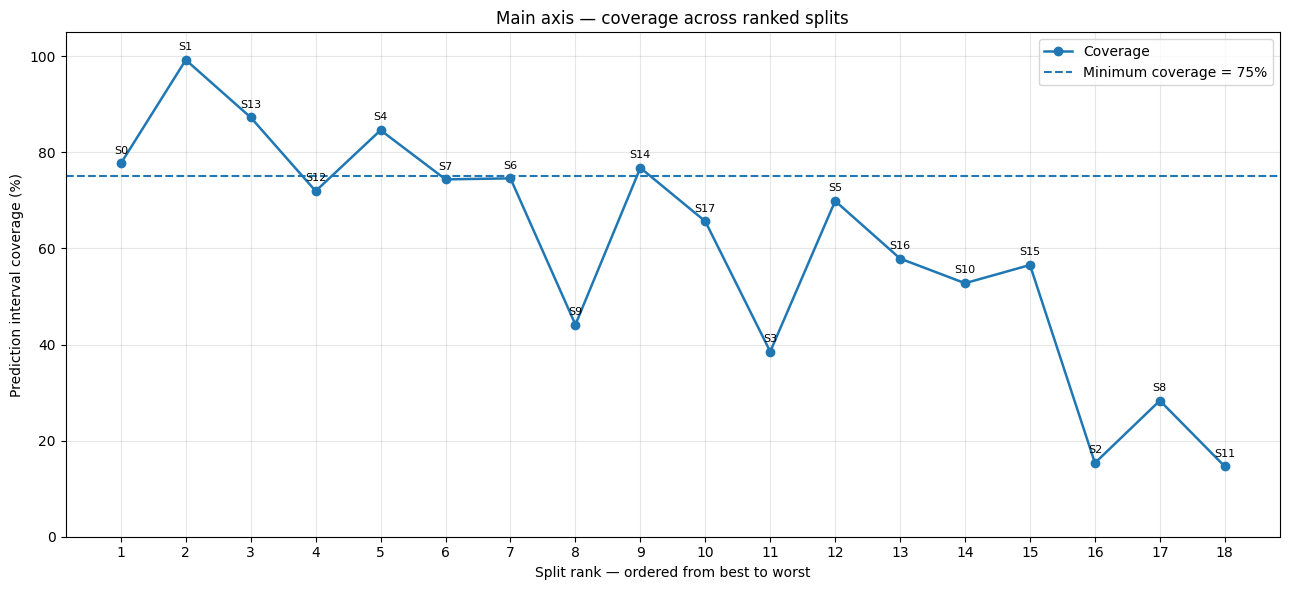

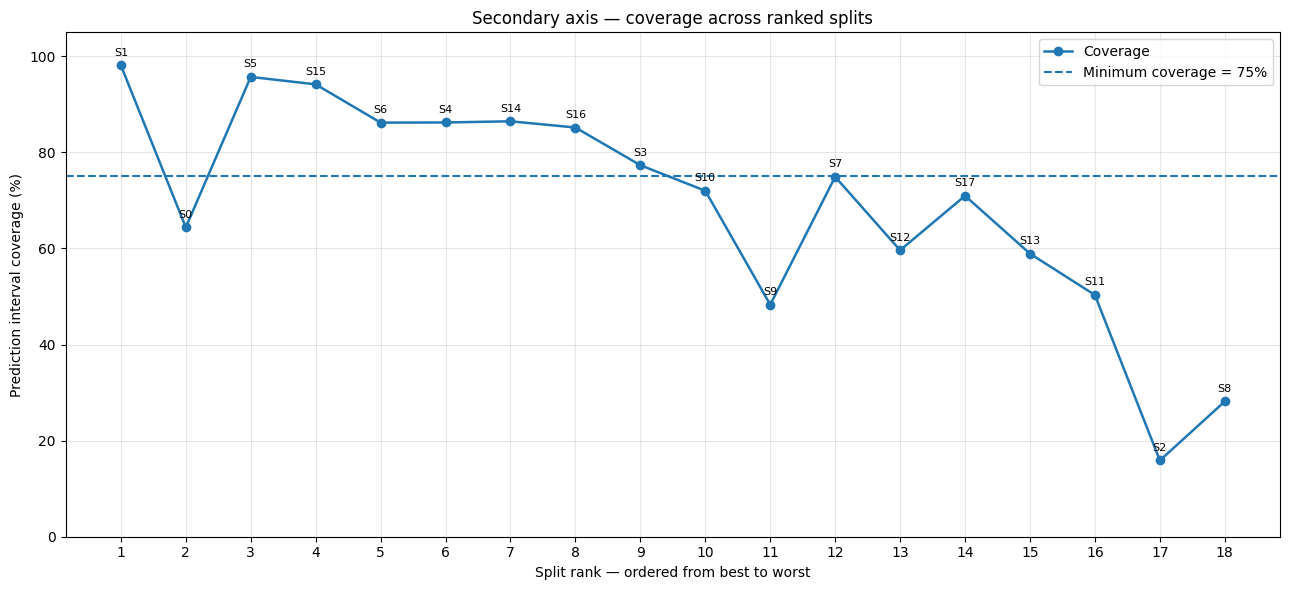

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Coverage versus ordered split
# ============================================================

def plot_coverage_by_rank(
    ranked_df,
    axis,
    minimum_coverage=75.0,
):
    """
    Plot final coverage for all splits ordered by the existing rank.

    No new ranking is performed.
    """

    required_columns = {
        "rank",
        "split_index",
        "axis_coverage_percent",
        "selection_status",
    }

    missing_columns = required_columns - set(ranked_df.columns)

    if missing_columns:
        raise KeyError(
            f"Missing columns: {sorted(missing_columns)}"
        )

    plot_df = (
        ranked_df[
            [
                "rank",
                "split_index",
                "axis_coverage_percent",
                "selection_status",
            ]
        ]
        .copy()
        .sort_values("rank")
        .reset_index(drop=True)
    )

    plot_df["rank"] = pd.to_numeric(
        plot_df["rank"],
        errors="raise",
    )

    plot_df["axis_coverage_percent"] = pd.to_numeric(
        plot_df["axis_coverage_percent"],
        errors="coerce",
    )

    figure, axis_object = plt.subplots(
        figsize=(13, 6)
    )

    axis_object.plot(
        plot_df["rank"],
        plot_df["axis_coverage_percent"],
        marker="o",
        linewidth=1.8,
        label="Coverage",
    )

    axis_object.axhline(
        y=minimum_coverage,
        linestyle="--",
        linewidth=1.5,
        label=f"Minimum coverage = {minimum_coverage:.0f}%",
    )

    for _, row in plot_df.iterrows():
        axis_object.annotate(
            text=f"S{int(row['split_index'])}",
            xy=(
                row["rank"],
                row["axis_coverage_percent"],
            ),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

    axis_object.set_title(
        f"{axis.capitalize()} axis — "
        "coverage across ranked splits"
    )

    axis_object.set_xlabel(
        "Split rank — ordered from best to worst"
    )

    axis_object.set_ylabel(
        "Prediction interval coverage (%)"
    )

    axis_object.set_xticks(
        plot_df["rank"]
    )

    axis_object.set_ylim(
        bottom=0,
        top=max(
            105,
            plot_df[
                "axis_coverage_percent"
            ].max() + 5,
        ),
    )

    axis_object.grid(
        alpha=0.3,
    )

    axis_object.legend()

    figure.tight_layout()
    plt.show()


# Main axis
plot_coverage_by_rank(
    ranked_df=main_ranked_splits_df,
    axis="main",
    minimum_coverage=75.0,
)

# Secondary axis
plot_coverage_by_rank(
    ranked_df=secondary_ranked_splits_df,
    axis="secondary",
    minimum_coverage=75.0,
)

coverage vs number of trees

In [16]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantile_forest import RandomForestQuantileRegressor


# ============================================================
# Configuration
# ============================================================

TREE_COUNTS = [
    10,
    25,
    50,
    100,
    200,
    300,
    500,
]

LOWER_QUANTILE = 0.025
UPPER_QUANTILE = 0.975

RANDOM_STATE = 42

# Set to None to run all splits.
#
# Examples:
# SELECTED_RANKS = [1, 2, 3]
# SELECTED_RANKS = [1, 2, 3, 16, 17, 18]
SELECTED_RANKS = None


# ============================================================
# Coverage calculation
# ============================================================

def calculate_coverage(
    y_true,
    lower_prediction,
    upper_prediction,
):
    y_true = np.asarray(y_true).reshape(-1)
    lower_prediction = np.asarray(
        lower_prediction
    ).reshape(-1)
    upper_prediction = np.asarray(
        upper_prediction
    ).reshape(-1)

    valid_mask = (
        np.isfinite(y_true)
        & np.isfinite(lower_prediction)
        & np.isfinite(upper_prediction)
    )

    if valid_mask.sum() == 0:
        return np.nan

    inside_interval = (
        (
            y_true[valid_mask]
            >= lower_prediction[valid_mask]
        )
        & (
            y_true[valid_mask]
            <= upper_prediction[valid_mask]
        )
    )

    return 100.0 * inside_interval.mean()


# ============================================================
# Run one axis
# ============================================================

def evaluate_tree_count_trend(
    ranked_df,
    axis,
    load_split_data_function,
    tree_counts=TREE_COUNTS,
    selected_ranks=SELECTED_RANKS,
):
    """
    Retrain QRF models using different numbers of trees.

    Parameters
    ----------
    ranked_df
        main_ranked_splits_df or
        secondary_ranked_splits_df.

    axis
        'main' or 'secondary'.

    load_split_data_function
        Your existing function that receives one ranked row and
        returns:

        X_train,
        X_validation,
        y_main_train,
        y_main_validation,
        y_secondary_train,
        y_secondary_validation
    """

    if axis not in {"main", "secondary"}:
        raise ValueError(
            "axis must be 'main' or 'secondary'."
        )

    experiment_df = ranked_df.copy()

    if selected_ranks is not None:
        experiment_df = experiment_df[
            experiment_df["rank"].isin(
                selected_ranks
            )
        ].copy()

    experiment_df = experiment_df.sort_values(
        "rank"
    )

    result_rows = []

    for _, split_row in experiment_df.iterrows():

        rank = int(split_row["rank"])
        split_index = int(
            split_row["split_index"]
        )

        print(
            f"\n{axis.upper()} AXIS | "
            f"rank={rank} | "
            f"split={split_index}"
        )

        (
            X_train,
            X_validation,
            y_main_train,
            y_main_validation,
            y_secondary_train,
            y_secondary_validation,
        ) = load_split_data_function(
            split_row
        )

        if axis == "main":
            y_train = y_main_train
            y_validation = y_main_validation
        else:
            y_train = y_secondary_train
            y_validation = y_secondary_validation

        y_train = np.asarray(
            y_train
        ).reshape(-1)

        y_validation = np.asarray(
            y_validation
        ).reshape(-1)

        for number_of_trees in tree_counts:

            print(
                f"  Training "
                f"{number_of_trees} trees..."
            )

            model = RandomForestQuantileRegressor(
                n_estimators=number_of_trees,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )

            model.fit(
                X_train,
                y_train,
            )

            interval_predictions = model.predict(
                X_validation,
                quantiles=[
                    LOWER_QUANTILE,
                    UPPER_QUANTILE,
                ],
            )

            interval_predictions = np.asarray(
                interval_predictions
            )

            lower_prediction = (
                interval_predictions[:, 0]
            )

            upper_prediction = (
                interval_predictions[:, 1]
            )

            coverage_percent = calculate_coverage(
                y_true=y_validation,
                lower_prediction=lower_prediction,
                upper_prediction=upper_prediction,
            )

            result_rows.append(
                {
                    "axis": axis,
                    "rank": rank,
                    "split_index": split_index,
                    "number_of_trees": (
                        number_of_trees
                    ),
                    "coverage_percent": (
                        coverage_percent
                    ),
                }
            )

            del model
            gc.collect()

    return pd.DataFrame(result_rows)


# ============================================================
# Run main and secondary separately
# ============================================================

main_tree_coverage_df = evaluate_tree_count_trend(
    ranked_df=main_ranked_splits_df,
    axis="main",
    load_split_data_function=load_split_data,
)

secondary_tree_coverage_df = evaluate_tree_count_trend(
    ranked_df=secondary_ranked_splits_df,
    axis="secondary",
    load_split_data_function=load_split_data,
)


MAIN AXIS | rank=1 | split=0


NameError: name '_train_test_frames_for_split' is not defined

In [17]:
load_split_data(split_row)

NameError: name 'split_row' is not defined

## Visualization of Split Sensitivity and QRF Convergence

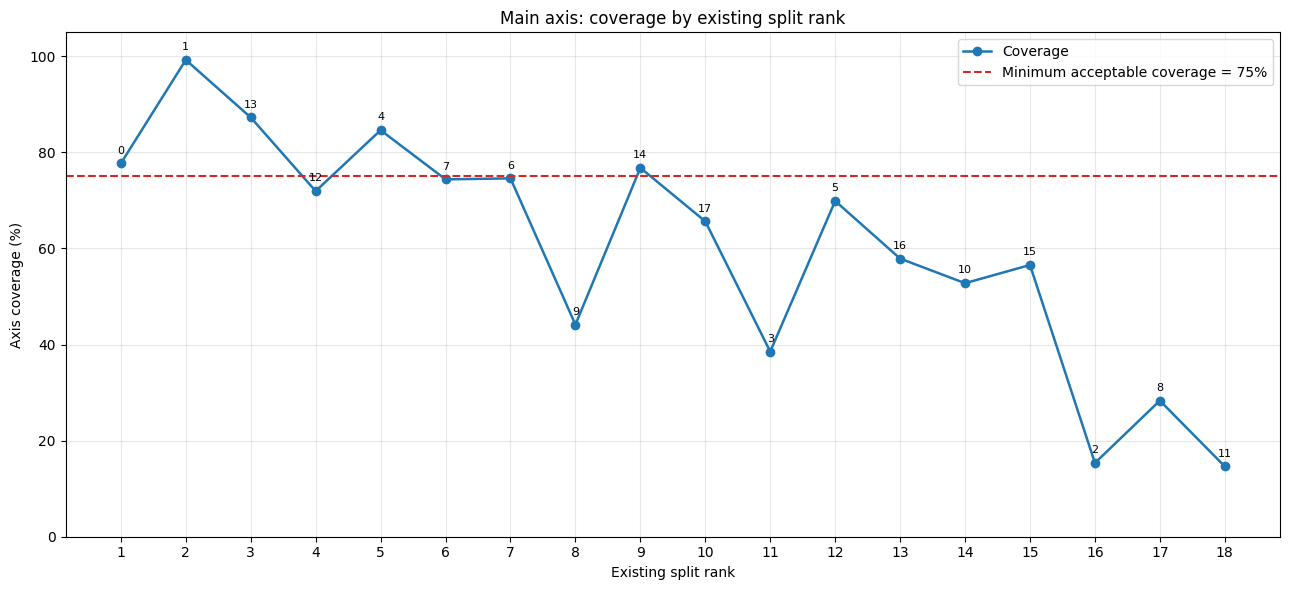

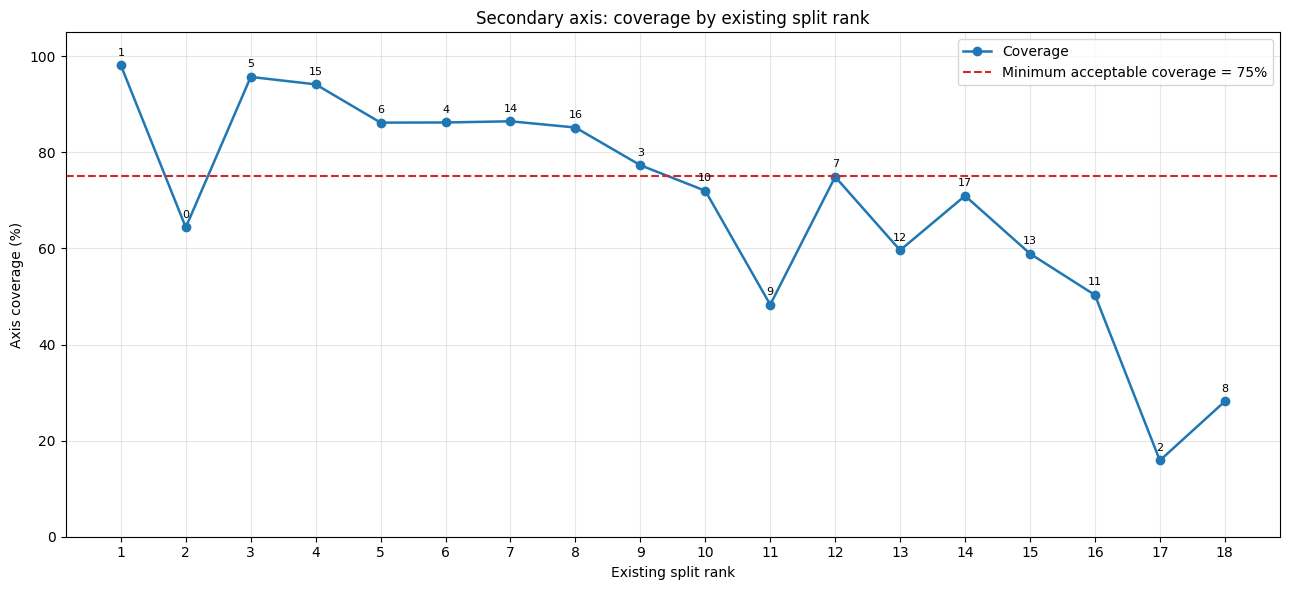

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def get_minimum_coverage_percent(default=75.0):
    value = globals().get("MIN_COVERAGE_PERCENT", default)

    try:
        return float(value)
    except (TypeError, ValueError):
        return float(default)


MINIMUM_COVERAGE_PERCENT = get_minimum_coverage_percent()


def plot_ranked_split_coverage(
    ranked_df,
    axis,
    minimum_coverage=MINIMUM_COVERAGE_PERCENT,
):
    required_columns = {
        "rank",
        "split_index",
        "axis_coverage_percent",
    }

    missing_columns = required_columns.difference(ranked_df.columns)

    if missing_columns:
        raise KeyError(
            f"Missing required columns for {axis}: {sorted(missing_columns)}"
        )

    plot_df = ranked_df[
        ["rank", "split_index", "axis_coverage_percent"]
    ].copy()

    plot_df["rank"] = pd.to_numeric(plot_df["rank"], errors="raise")
    plot_df["split_index"] = pd.to_numeric(plot_df["split_index"], errors="raise")
    plot_df["axis_coverage_percent"] = pd.to_numeric(
        plot_df["axis_coverage_percent"],
        errors="coerce",
    )

    plot_df = plot_df.sort_values("rank").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(
        plot_df["rank"],
        plot_df["axis_coverage_percent"],
        marker="o",
        linewidth=1.8,
        label="Coverage",
    )

    ax.axhline(
        minimum_coverage,
        linestyle="--",
        linewidth=1.5,
        color="tab:red",
        label=f"Minimum acceptable coverage = {minimum_coverage:.0f}%",
    )

    for _, row in plot_df.iterrows():
        ax.annotate(
            f"{int(row['split_index'])}",
            xy=(row["rank"], row["axis_coverage_percent"]),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

    ax.set_title(f"{axis.capitalize()} axis: coverage by existing split rank")
    ax.set_xlabel("Existing split rank")
    ax.set_ylabel("Axis coverage (%)")
    ax.set_xticks(plot_df["rank"].tolist())
    ax.set_ylim(
        bottom=0,
        top=max(105, float(plot_df["axis_coverage_percent"].max()) + 5),
    )
    ax.grid(alpha=0.3)
    ax.legend()

    fig.tight_layout()
    plt.show()


plot_ranked_split_coverage(main_ranked_splits_df, axis="main")
plot_ranked_split_coverage(secondary_ranked_splits_df, axis="secondary")

In [19]:
import ast
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve()

if project_root.name == "exploration":
    project_root = project_root.parent

if not (project_root / "data").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pipeline.ml.qrf.geometry_data_preprocessor import GeometryPreprocessor
from src.pipeline.ml.qrf.qrf_pipeline import qrf_training_geometry_sources
from src.pipeline.rf_augmentation.io_utils import read_table


geometry_source = globals().get(
    "geometry_source",
    globals().get(
        "SOURCE_TO_KEEP",
        "sensor_augmented_noise__time_wrapping__scaling__jittering",
    ),
)

split_metadata_path = (
    project_root
    / "exploration"
    / "data"
    / "qrf"
    / "split"
    / "various_splits.parquet"
)

if not split_metadata_path.exists():
    raise FileNotFoundError(split_metadata_path)

various_splits_df = pd.read_parquet(split_metadata_path)


def parse_experiment_numbers(value):
    if isinstance(value, str):
        value = ast.literal_eval(value)

    if isinstance(value, (list, tuple, set)):
        return [int(exp_id) for exp_id in value]

    return [int(value)]


excluded_experiments = {1, 48, 166}

bending_setup_path = (
    project_root
    / "data"
    / "rf_augmented"
    / "ui_data"
    / "unique_bending_setups.csv"
)

bending_for_qrf = pd.read_csv(bending_setup_path)

bending_for_qrf["Experiment_Number"] = (
    bending_for_qrf["Experiment_Number"]
    .apply(parse_experiment_numbers)
    .apply(
        lambda experiment_ids: [
            exp_id
            for exp_id in experiment_ids
            if exp_id not in excluded_experiments
        ]
    )
)

bending_for_qrf = (
    bending_for_qrf[
        bending_for_qrf["Experiment_Number"].apply(len) > 0
    ]
    .reset_index(drop=True)
)

if "Group_ID" not in bending_for_qrf.columns:
    bending_for_qrf.insert(
        0,
        "Group_ID",
        range(1, len(bending_for_qrf) + 1),
    )

available_geometry_sources = qrf_training_geometry_sources(project_root)

if geometry_source not in available_geometry_sources:
    raise KeyError(
        f"Geometry source '{geometry_source}' was not found. "
        f"Available sources: {list(available_geometry_sources.keys())}"
    )

geometry_path = available_geometry_sources[geometry_source]
geometry = read_table(geometry_path)

geometry_clean = GeometryPreprocessor.preprocess(
    geometry_df=geometry,
    bending_df=bending_for_qrf,
)

print(f"Loaded split metadata: {len(various_splits_df):,} rows")
print(f"Loaded geometry_clean: {len(geometry_clean):,} rows")
print(f"Geometry source: {geometry_source}")

2026-07-20 17:40:48,650 | INFO | src.logging.log_utils | Started GeometryPreprocessor.preprocess
2026-07-20 17:40:48,656 | INFO | src.logging.log_utils | Finished GeometryPreprocessor.preprocess


Loaded split metadata: 54,000 rows
Loaded geometry_clean: 27,000 rows
Geometry source: sensor_augmented_noise__time_wrapping__scaling__jittering


In [20]:
import gc
import json
from pathlib import Path
import ast

import numpy as np
import pandas as pd
from quantile_forest import RandomForestQuantileRegressor


TREE_COUNTS = [10, 25, 50, 100, 200, 300, 500]

QRF_FEATURE_COLUMNS = [
    "Group_ID",
    "Angle[degree]ORDistance[mm]",
]

QRF_TARGET_COLUMNS = {
    "main": "Main-axis [mm]",
    "secondary": "Secondary-axis [mm]",
}

QRF_MODEL_DEFAULTS = {
    "max_depth": 20,
    "min_samples_leaf": 1,
    "min_samples_split": 2,
    "max_features": 1.0,
    "bootstrap": True,
    "random_state": 1100,
    "lower_quantile": 0.05,
    "upper_quantile": 0.95,
}


def _coalesce_notna(*values):
    for value in values:
        if value is None:
            continue
        try:
            if pd.isna(value):
                continue
        except (TypeError, ValueError):
            pass
        return value
    return None


def _qrf_param_from_row(split_row, param_name):
    configured_params = globals().get("qrf_params", {}) or {}

    value = _coalesce_notna(
        split_row.get(f"config_{param_name}"),
        configured_params.get(param_name),
        QRF_MODEL_DEFAULTS[param_name],
    )

    if param_name in {
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "random_state",
    }:
        return int(value)

    if param_name == "bootstrap":
        return bool(value)

    return value


def _qrf_quantile_from_row(split_row, quantile_name):
    configured_params = globals().get("qrf_params", {}) or {}

    return float(
        _coalesce_notna(
            split_row.get(f"config_{quantile_name}"),
            configured_params.get(quantile_name),
            QRF_MODEL_DEFAULTS[quantile_name],
        )
    )


def _decode_int_list(value):
    if isinstance(value, str):
        value = json.loads(value)

    if isinstance(value, np.ndarray):
        value = value.tolist()

    return [int(item) for item in value]


def _get_split_metadata_df():
    if "various_splits_df" in globals():
        return various_splits_df.copy()

    candidate_paths = []

    if "output_path" in globals():
        candidate_paths.append(output_path)

    if "project_root" in globals():
        candidate_paths.append(
            project_root / "data" / "qrf" / "split" / "various_splits.parquet"
        )

    candidate_paths.append(
        Path.cwd() / "data" / "qrf" / "split" / "various_splits.parquet"
    )
    candidate_paths.append(
        Path.cwd().parent / "data" / "qrf" / "split" / "various_splits.parquet"
    )

    for candidate_path in candidate_paths:
        candidate_path = Path(candidate_path)
        if candidate_path.exists():
            return pd.read_parquet(candidate_path)

    raise FileNotFoundError(
        "Could not find various_splits_df or data/qrf/split/various_splits.parquet."
    )


def _get_preprocessed_geometry_df():
    if "geometry_clean" in globals():
        return geometry_clean.copy()

    if "bending_for_qrf" not in globals():
        raise NameError("bending_for_qrf is not available from the existing pipeline.")

    root = globals().get("project_root", Path.cwd().resolve())
    root = Path(root)

    if not (root / "data").exists():
        root = root.parent

    selected_geometry_source = globals().get(
        "geometry_source",
        SOURCE_TO_KEEP if "SOURCE_TO_KEEP" in globals() else None,
    )

    if selected_geometry_source is None:
        raise NameError("geometry_source is not available from the existing pipeline.")

    available_sources = qrf_training_geometry_sources(root)
    geometry_path = available_sources[selected_geometry_source]
    geometry = read_table(geometry_path)

    return GeometryPreprocessor.preprocess(
        geometry_df=geometry,
        bending_df=bending_for_qrf,
    )


def _split_group_ids(split_index):
    split_metadata_df = _get_split_metadata_df()
    split_rows = split_metadata_df[
        pd.to_numeric(
            split_metadata_df["split_index"],
            errors="coerce",
        ).eq(int(split_index))
    ]

    if split_rows.empty:
        raise ValueError(f"No split metadata found for split_index={split_index}.")

    split_row = split_rows.iloc[0]

    return (
        _decode_int_list(split_row["train_group_ids"]),
        _decode_int_list(split_row["test_group_ids"]),
    )


def _train_test_frames_for_split(split_index):
    geometry_df = _get_preprocessed_geometry_df()
    train_group_ids, test_group_ids = _split_group_ids(split_index)

    train_df = geometry_df[
        geometry_df["Group_ID"].isin(train_group_ids)
    ].copy()

    test_df = geometry_df[
        geometry_df["Group_ID"].isin(test_group_ids)
    ].copy()

    if train_df.empty:
        raise ValueError(f"Empty train_df for split_index={split_index}.")

    if test_df.empty:
        raise ValueError(f"Empty test_df for split_index={split_index}.")

    return train_df, test_df


def _selected_rank_rows(ranked_df):
    working_df = ranked_df.copy()
    working_df["rank"] = pd.to_numeric(working_df["rank"], errors="raise")
    working_df["split_index"] = pd.to_numeric(
        working_df["split_index"],
        errors="raise",
    )

    max_rank = int(working_df["rank"].max())

    top_df = working_df[working_df["rank"].isin([1, 2, 3])].copy()
    worst_df = working_df[working_df["rank"] >= max_rank - 2].copy()

    top_df["rank_group"] = "top"
    worst_df["rank_group"] = "worst"

    selected_df = pd.concat([top_df, worst_df], ignore_index=True)

    return (
        selected_df
        .drop_duplicates(subset=["rank", "split_index"], keep="first")
        .sort_values(["rank_group", "rank"])
    )


def _coverage_percent(y_true, y_pred_lower, y_pred_upper):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred_lower = np.asarray(y_pred_lower).reshape(-1)
    y_pred_upper = np.asarray(y_pred_upper).reshape(-1)

    inside_interval = (y_true >= y_pred_lower) & (y_true <= y_pred_upper)

    return float(100.0 * inside_interval.mean())


def evaluate_qrf_tree_coverage(ranked_df, axis, tree_counts=TREE_COUNTS):
    result_rows = []
    target_column = QRF_TARGET_COLUMNS[axis]

    for _, split_row in _selected_rank_rows(ranked_df).iterrows():
        rank = int(split_row["rank"])
        rank_group = split_row["rank_group"]
        split_index = int(split_row["split_index"])

        train_df, test_df = _train_test_frames_for_split(split_index)

        X_train = train_df[QRF_FEATURE_COLUMNS]
        X_test = test_df[QRF_FEATURE_COLUMNS]
        y_train = train_df[target_column]
        y_test = test_df[target_column]

        lower_quantile = _qrf_quantile_from_row(split_row, "lower_quantile")
        upper_quantile = _qrf_quantile_from_row(split_row, "upper_quantile")

        print(
            f"{axis} | {rank_group} | rank={rank} | "
            f"split_index={split_index} | test_rows={len(test_df):,}"
        )

        for number_of_trees in tree_counts:
            model = RandomForestQuantileRegressor(
                n_estimators=int(number_of_trees),
                max_depth=_qrf_param_from_row(split_row, "max_depth"),
                min_samples_leaf=_qrf_param_from_row(split_row, "min_samples_leaf"),
                min_samples_split=_qrf_param_from_row(split_row, "min_samples_split"),
                max_features=_qrf_param_from_row(split_row, "max_features"),
                bootstrap=_qrf_param_from_row(split_row, "bootstrap"),
                random_state=_qrf_param_from_row(split_row, "random_state"),
                n_jobs=-1,
            )

            model.fit(X_train, y_train)

            y_pred_lower = model.predict(X_test, quantiles=lower_quantile)
            y_pred_upper = model.predict(X_test, quantiles=upper_quantile)

            result_rows.append(
                {
                    "axis": axis,
                    "rank_group": rank_group,
                    "rank": rank,
                    "split_index": split_index,
                    "number_of_trees": int(number_of_trees),
                    "coverage_percent": _coverage_percent(
                        y_test,
                        y_pred_lower,
                        y_pred_upper,
                    ),
                }
            )

            del model
            gc.collect()

    return pd.DataFrame(result_rows)


main_tree_coverage_df = evaluate_qrf_tree_coverage(
    main_ranked_splits_df,
    axis="main",
)

secondary_tree_coverage_df = evaluate_qrf_tree_coverage(
    secondary_ranked_splits_df,
    axis="secondary",
)

display(main_tree_coverage_df)
display(secondary_tree_coverage_df)

main | top | rank=1 | split_index=0 | test_rows=1,080
main | top | rank=2 | split_index=1 | test_rows=1,080
main | top | rank=3 | split_index=13 | test_rows=1,080
main | worst | rank=16 | split_index=2 | test_rows=1,080
main | worst | rank=17 | split_index=8 | test_rows=1,080
main | worst | rank=18 | split_index=11 | test_rows=2,430
secondary | top | rank=1 | split_index=1 | test_rows=1,080
secondary | top | rank=2 | split_index=0 | test_rows=1,080
secondary | top | rank=3 | split_index=5 | test_rows=1,080
secondary | worst | rank=16 | split_index=11 | test_rows=2,430
secondary | worst | rank=17 | split_index=2 | test_rows=1,080
secondary | worst | rank=18 | split_index=8 | test_rows=1,080


,axis,rank_group,rank,split_index,number_of_trees,coverage_percent
0,main,top,1,0,10,57.685185
1,main,top,1,0,25,62.592593
2,main,top,1,0,50,67.037037
3,main,top,1,0,100,68.333333
4,main,top,1,0,200,71.574074
5,main,top,1,0,300,68.981481
6,main,top,1,0,500,68.055556
7,main,top,2,1,10,70.462963
8,main,top,2,1,25,58.703704
9,main,top,2,1,50,65.740741


,axis,rank_group,rank,split_index,number_of_trees,coverage_percent
0,secondary,top,1,1,10,52.870370
1,secondary,top,1,1,25,60.000000
2,secondary,top,1,1,50,62.500000
3,secondary,top,1,1,100,66.018519
4,secondary,top,1,1,200,70.370370
5,secondary,top,1,1,300,73.981481
6,secondary,top,1,1,500,74.537037
7,secondary,top,2,0,10,20.555556
8,secondary,top,2,0,25,24.814815
9,secondary,top,2,0,50,25.555556


    axis rank_group  rank  split_index  number_of_trees  coverage_percent
0   main        top     1            0               10         57.685185
1   main        top     1            0               25         62.592593
2   main        top     1            0               50         67.037037
3   main        top     1            0              100         68.333333
4   main        top     1            0              200         71.574074
5   main        top     1            0              300         68.981481
6   main        top     1            0              500         68.055556
7   main        top     2            1               10         70.462963
8   main        top     2            1               25         58.703704
9   main        top     2            1               50         65.740741
10  main        top     2            1              100         70.277778
11  main        top     2            1              200         72.222222
12  main        top     2            1

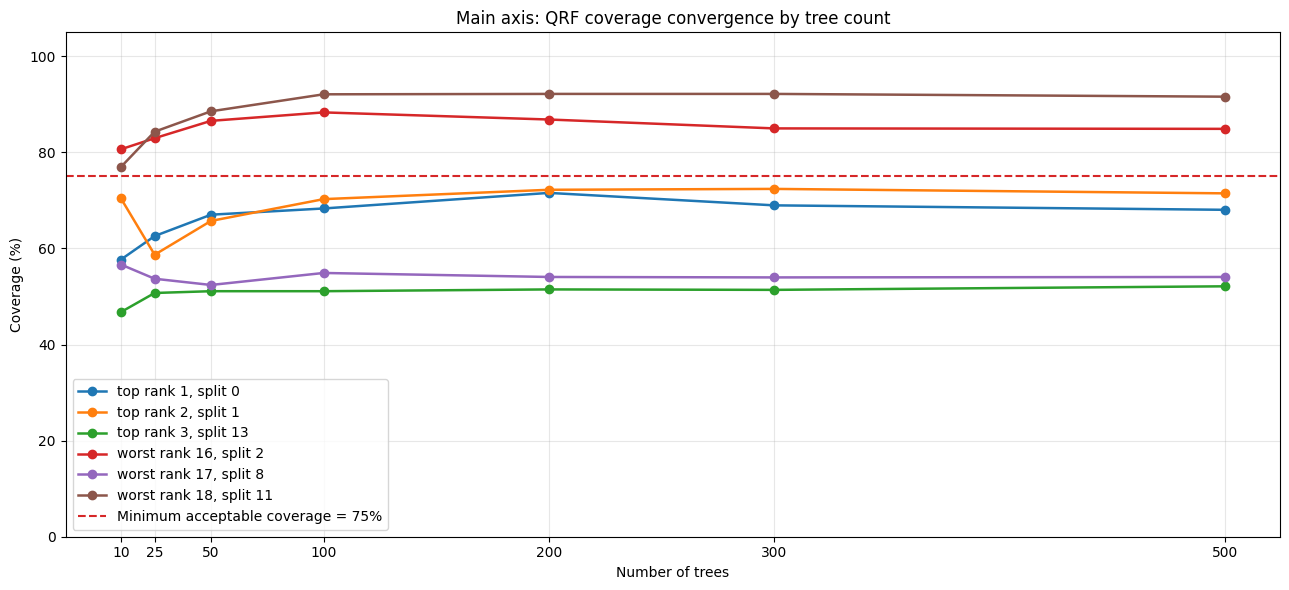

         axis rank_group  rank  split_index  number_of_trees  coverage_percent
0   secondary        top     1            1               10         52.870370
1   secondary        top     1            1               25         60.000000
2   secondary        top     1            1               50         62.500000
3   secondary        top     1            1              100         66.018519
4   secondary        top     1            1              200         70.370370
5   secondary        top     1            1              300         73.981481
6   secondary        top     1            1              500         74.537037
7   secondary        top     2            0               10         20.555556
8   secondary        top     2            0               25         24.814815
9   secondary        top     2            0               50         25.555556
10  secondary        top     2            0              100         29.444444
11  secondary        top     2            0         

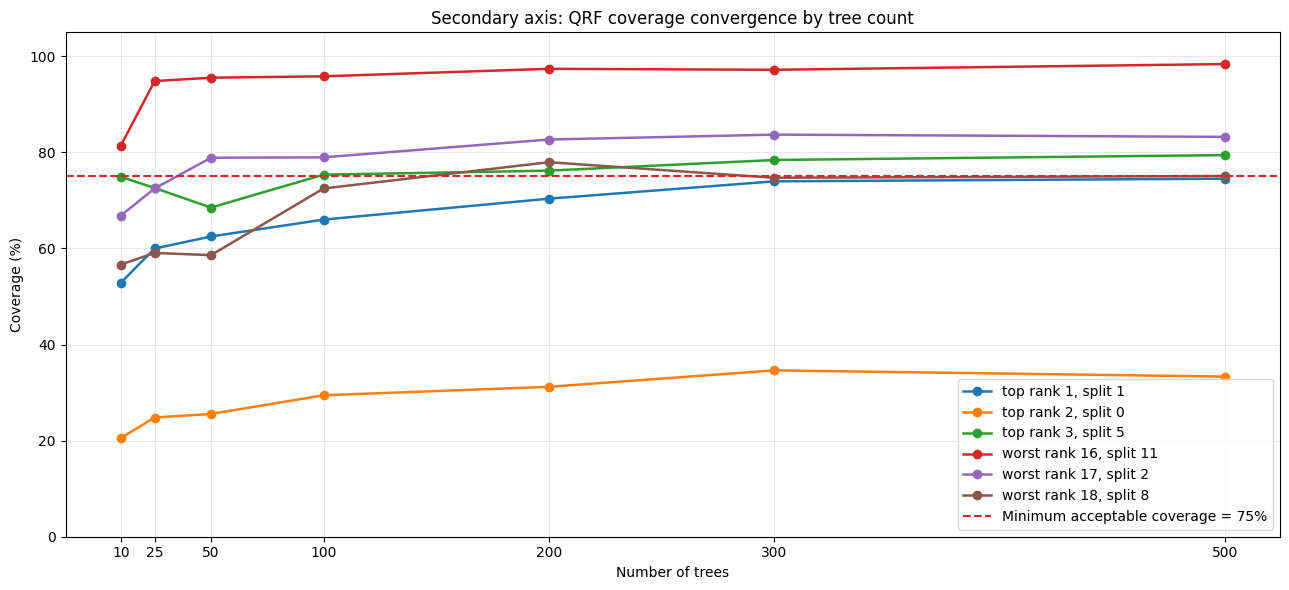

In [ ]:
import matplotlib.pyplot as plt

MINIMUM_COVERAGE_PERCENT = globals().get("MINIMUM_COVERAGE_PERCENT", 75.0)

def plot_tree_coverage_convergence(
    tree_coverage_df,
    axis,
    minimum_coverage=MINIMUM_COVERAGE_PERCENT,
):
    plot_df = tree_coverage_df[
        tree_coverage_df["axis"].eq(axis)
    ].copy()

    if plot_df.empty:
        raise ValueError(f"No tree-coverage rows are available for axis={axis}.")
    
    if "split_name" not in plot_df.columns:
        plot_df["split_name"] = plot_df["split_index"].apply(
            lambda split_index: f"split {int(split_index)}"
        )

    plot_df = plot_df.sort_values(
        ["rank_group", "rank", "split_name", "number_of_trees"]
    )

    fig, ax = plt.subplots(figsize=(13, 6))

    for (rank_group, rank, split_name), split_df in plot_df.groupby(
        ["rank_group", "rank", "split_name"],
        sort=True,
    ):
        split_df = split_df.sort_values("number_of_trees")

        ax.plot(
            split_df["number_of_trees"],
            split_df["coverage_percent"],
            marker="o",
            linewidth=1.8,
            label=f"{rank_group} rank {int(rank)}, {split_name}",
        )

    ax.axhline(
        minimum_coverage,
        linestyle="--",
        linewidth=1.5,
        color="tab:red",
        label=f"Minimum acceptable coverage = {minimum_coverage:.0f}%",
    )

    ax.set_title(f"{axis.capitalize()} axis: QRF coverage convergence by tree count")
    ax.set_xlabel("Number of trees")
    ax.set_ylabel("Coverage (%)")
    ax.set_xticks(TREE_COUNTS)
    ax.set_ylim(
        bottom=0,
        top=max(105, float(plot_df["coverage_percent"].max()) + 5),
    )
    ax.grid(alpha=0.3)
    ax.legend(loc="best")

    fig.tight_layout()
    plt.show()


plot_tree_coverage_convergence(main_tree_coverage_df, axis="main")
plot_tree_coverage_convergence(secondary_tree_coverage_df, axis="secondary")

In [32]:
main_ranked_splits_df['metric_split_name']

0     Clamp-die lateral position = 225.25
1     Clamp-die lateral position = 225.35
2               Pressure-die boost = 0.85
3                Pressure-die boost = 0.0
4                     Collet boost = 0.87
5                     Collet boost = 0.95
6                     Collet boost = 0.92
7         Mandrel retraction timing = 2.0
8               Pressure-die boost = 0.87
9               Pressure-die boost = 0.95
10                    Collet boost = 0.85
11                     Collet boost = 0.9
12              Pressure-die boost = 0.92
13        Mandrel retraction timing = 5.0
14               Pressure-die boost = 0.9
15     Clamp-die lateral position = 225.4
16        Mandrel retraction timing = 0.0
17       Mandrel retraction timing = 10.0
Name: metric_split_name, dtype: object